In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu

warnings.filterwarnings("ignore")

# ── Paden ──────────────────────────────────────────────────────────────────
DATA_DIR = Path.cwd().parent / "TimingStrategies_28_05"

s1 = pd.read_csv(DATA_DIR / "s1_periodic.csv")
s2 = pd.read_csv(DATA_DIR / "s2_event_driven.csv")
s3 = pd.read_csv(DATA_DIR / "s3_hybrid.csv")

# Voeg alles samen
raw_all = pd.concat([s1, s2, s3], ignore_index=True)

# Zorg dat deadlock boolean is
raw_all["deadlock"] = raw_all["deadlock"].astype(str).str.lower() == "true"

print(f"Geladen: {len(raw_all)} rijen")
print(f"  s1_periodic:     {len(s1)} rijen")
print(f"  s2_event_driven: {len(s2)} rijen")
print(f"  s3_hybrid:       {len(s3)} rijen")
print(f"\nData directory: {DATA_DIR.resolve()}")
print(f"\nKolommen: {list(raw_all.columns)}")

Geladen: 1887 rijen
  s1_periodic:     250 rijen
  s2_event_driven: 1300 rijen
  s3_hybrid:       337 rijen

Data directory: C:\Users\Allice\Thesis\TimingStrategies_28_05

Kolommen: ['label', 'seed', 'trigger_strategy', 'event_driven_freq', 'controller_freq', 'periodic_freq', 'threshold_confidence', 'TED_combined', 'TED_passenger', 'TED_freight', 'delay_ratio', 'n_delay_gt3min', 'n_delay_gt5min', 'max_end_delay', 'n_rescheduled', 'n_evaluated', 'n_skipped_no_improvement', 'total_solve_time_s', 'mean_solve_time_s', 'trigger_rate_pct', 'trigger_rate_mc_pct', 'n_platform_switches', 'n_fcfs_fallback', 'deadlock']


In [2]:
# ── Samenvatting & filtering ──────────────────────────────────────────────
TRIGGER_ORDER = ["periodic", "event_driven", "hybrid"]

n_deadlock = raw_all["deadlock"].sum()
print(f"Deadlocks: {n_deadlock} runs (worden uitgesloten van metric-analyses)")

raw = raw_all[~raw_all["deadlock"]].copy()
raw["trigger"] = pd.Categorical(raw["trigger_strategy"], categories=TRIGGER_ORDER, ordered=True)

# Splits per strategie — hier gedefinieerd zodat alle cellen ze kunnen gebruiken
raw_periodic = raw_all[raw_all["trigger_strategy"] == "periodic"]
raw_event    = raw_all[raw_all["trigger_strategy"] == "event_driven"]
raw_hybrid   = raw_all[raw_all["trigger_strategy"] == "hybrid"]

print(f"\nNa filtering deadlocks: {len(raw)} rijen voor analyse")
print(f"\nDistributie per strategie:")
print(raw_all.groupby("trigger_strategy").agg(
    totaal=("seed", "count"),
    deadlocks=("deadlock", "sum"),
).to_string())

Deadlocks: 49 runs (worden uitgesloten van metric-analyses)

Na filtering deadlocks: 1838 rijen voor analyse

Distributie per strategie:
                  totaal  deadlocks
trigger_strategy                   
event_driven        1300         35
hybrid               337          7
periodic             250          7


In [3]:
print("Beschikbare kolommen:")
print(list(raw_all.columns))
raw_all.head(3)

Beschikbare kolommen:
['label', 'seed', 'trigger_strategy', 'event_driven_freq', 'controller_freq', 'periodic_freq', 'threshold_confidence', 'TED_combined', 'TED_passenger', 'TED_freight', 'delay_ratio', 'n_delay_gt3min', 'n_delay_gt5min', 'max_end_delay', 'n_rescheduled', 'n_evaluated', 'n_skipped_no_improvement', 'total_solve_time_s', 'mean_solve_time_s', 'trigger_rate_pct', 'trigger_rate_mc_pct', 'n_platform_switches', 'n_fcfs_fallback', 'deadlock']


,label,seed,trigger_strategy,event_driven_freq,controller_freq,periodic_freq,threshold_confidence,TED_combined,TED_passenger,TED_freight,...,n_rescheduled,n_evaluated,n_skipped_no_improvement,total_solve_time_s,mean_solve_time_s,trigger_rate_pct,trigger_rate_mc_pct,n_platform_switches,n_fcfs_fallback,deadlock
0,P_100000,0,periodic,100000.0,100000.0,100000.0,0.6,45351.3,37154.5,8196.8,...,0,0,0,0.0,0.0,0.0,0.0,0,0,False
1,P_100000,1,periodic,100000.0,100000.0,100000.0,0.6,47273.9,40960.1,6313.8,...,0,0,0,0.0,0.0,0.0,0.0,0,0,False
2,P_100000,2,periodic,100000.0,100000.0,100000.0,0.6,45657.7,37113.7,8544.0,...,0,0,0,0.0,0.0,0.0,0.0,0,0,False


---
## Periodic

In [4]:
raw_periodic = raw_all[raw_all["trigger_strategy"] == "periodic"]
print(f"Periodic runs: {len(raw_periodic)} | deadlocks: {raw_periodic['deadlock'].sum()}")
print(f"periodic_freq waarden: {sorted(raw_periodic['periodic_freq'].unique())}")

Periodic runs: 250 | deadlocks: 7
periodic_freq waarden: [np.float64(450.0), np.float64(900.0), np.float64(1800.0), np.float64(3600.0), np.float64(100000.0)]


In [5]:
raw_periodic.head()

,label,seed,trigger_strategy,event_driven_freq,controller_freq,periodic_freq,threshold_confidence,TED_combined,TED_passenger,TED_freight,...,n_rescheduled,n_evaluated,n_skipped_no_improvement,total_solve_time_s,mean_solve_time_s,trigger_rate_pct,trigger_rate_mc_pct,n_platform_switches,n_fcfs_fallback,deadlock
0,P_100000,0,periodic,100000.0,100000.0,100000.0,0.6,45351.3,37154.5,8196.8,...,0,0,0,0.0,0.0,0.0,0.0,0,0,False
1,P_100000,1,periodic,100000.0,100000.0,100000.0,0.6,47273.9,40960.1,6313.8,...,0,0,0,0.0,0.0,0.0,0.0,0,0,False
2,P_100000,2,periodic,100000.0,100000.0,100000.0,0.6,45657.7,37113.7,8544.0,...,0,0,0,0.0,0.0,0.0,0.0,0,0,False
3,P_100000,3,periodic,100000.0,100000.0,100000.0,0.6,42222.5,35430.2,6792.3,...,0,0,0,0.0,0.0,0.0,0.0,0,0,False
4,P_100000,4,periodic,100000.0,100000.0,100000.0,0.6,45189.7,38812.8,6376.9,...,0,0,0,0.0,0.0,0.0,0.0,0,0,False


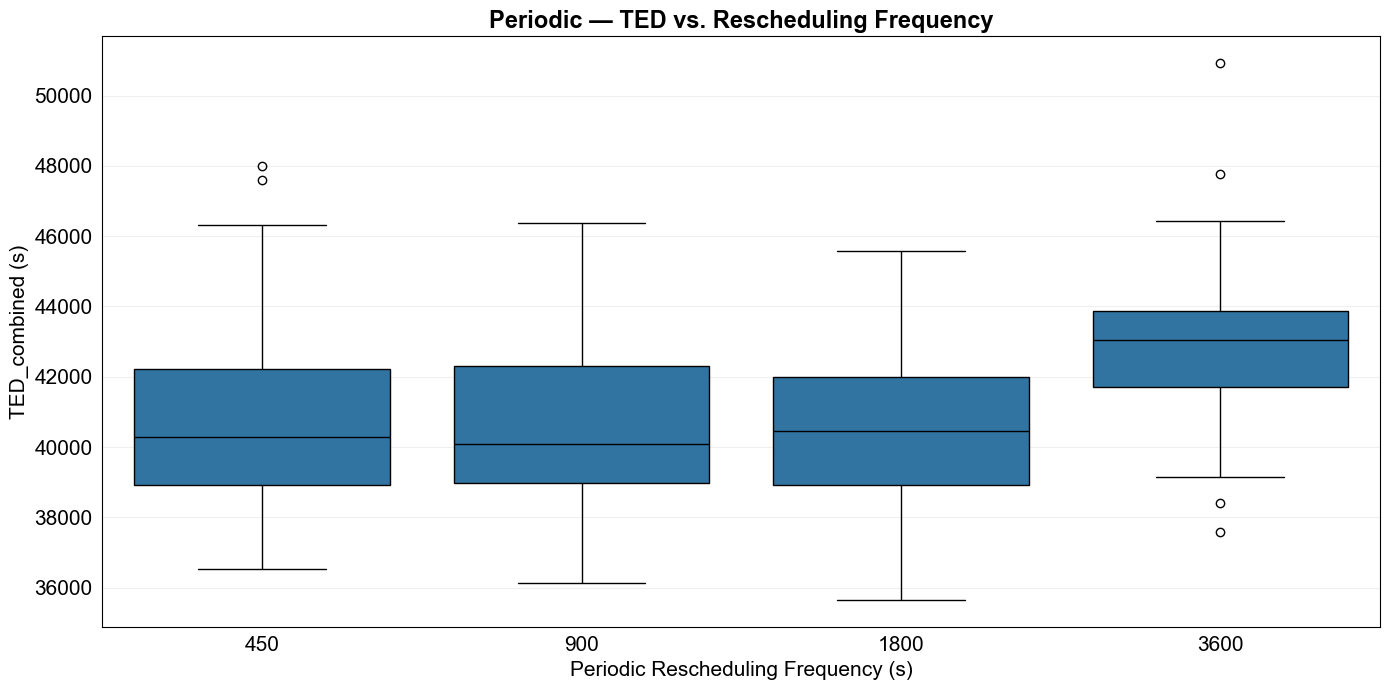

In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# Filter periodic strategies
# ============================================================

periodic_df = raw_periodic.copy()

# Exclude baseline / no-rescheduling
periodic_df = periodic_df[periodic_df["periodic_freq"] != 100000]

freq_order = sorted(periodic_df["periodic_freq"].unique())

# Enkel non-deadlock runs voor de boxplots
plot_df = periodic_df[~periodic_df["deadlock"]].copy()

# ============================================================
# TED BOXPLOT
# ============================================================

fig, ax = plt.subplots(figsize=(14, 7))

sns.boxplot(
    data=plot_df,
    x="periodic_freq",
    y="TED_combined",
    order=freq_order,
    ax=ax,
    linecolor="black",
    flierprops={"markeredgecolor": "black"}
)

ax.set_xticklabels([f"{int(f)}" for f in freq_order], fontsize=15)
ax.tick_params(axis="y", labelsize=15, colors="black")
ax.tick_params(axis="x", colors="black")
ax.spines["bottom"].set_color("black")
ax.spines["top"].set_color("black")
ax.spines["left"].set_color("black")
ax.spines["right"].set_color("black")
plt.title("Periodic — TED vs. Rescheduling Frequency", fontsize=17, color="black", fontweight="bold")
plt.xlabel("Periodic Rescheduling Frequency (s)", fontsize=15, color="black")
plt.ylabel("TED_combined (s)", fontsize=15, color="black")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
summary = (
    raw_periodic
    .groupby("label")
    .agg(
        Mean_TED=("TED_combined", "mean"),
        Std_TED=("TED_combined", "std"),
        Mean_Reschedules=("n_rescheduled", "mean"),
        Deadlocks=("deadlock", "sum")
    )
)

summary["CV"] = (summary["Std_TED"] / summary["Mean_TED"]).round(3)
summary["CV"] = (summary["Std_TED"] / summary["Mean_TED"]).round(3)
summary["Std_TED"] = summary["Std_TED"].round(2)


summary.index.name = "Config"
summary.columns = ["Mean TED (s)", "Std (s)", "Mean #Reschedules", "Deadlocks", "CV"]
summary = summary[["Mean TED (s)", "Std (s)", "Mean #Reschedules", "CV", "Deadlocks"]]
summary = summary.loc[["P_450", "P_900", "P_1800", "P_3600", "P_100000"]]

display(summary.style.set_table_styles(
    [{"selector": "th", "props": [("white-space", "nowrap")]}]
))

,Mean TED (s),Std (s),Mean #Reschedules,CV,Deadlocks
Config,,,,,
P_450,40765.808010,2670.800000,86.480000,0.066000,0
P_900,40582.935256,2662.680000,46.480000,0.066000,1
P_1800,40450.488000,2474.740000,28.240000,0.061000,2
P_3600,42963.536000,2410.930000,20.060000,0.056000,2
P_100000,46588.770000,4021.240000,0.000000,0.086000,2


In [25]:
baseline_mean = raw_periodic[raw_periodic["periodic_freq"] == 100000]["TED_combined"].mean()

for freq in [450, 900, 1800, 3600]:
    mean_ted = raw_periodic[
        (raw_periodic["periodic_freq"] == freq) & 
        (~raw_periodic["deadlock"])
    ]["TED_combined"].mean()
    pct_change = (mean_ted - baseline_mean) / baseline_mean * 100
    print(f"P_{int(freq)}: {pct_change:+.1f}% vs baseline")

P_450: -12.5% vs baseline
P_900: -12.6% vs baseline
P_1800: -12.8% vs baseline
P_3600: -7.7% vs baseline


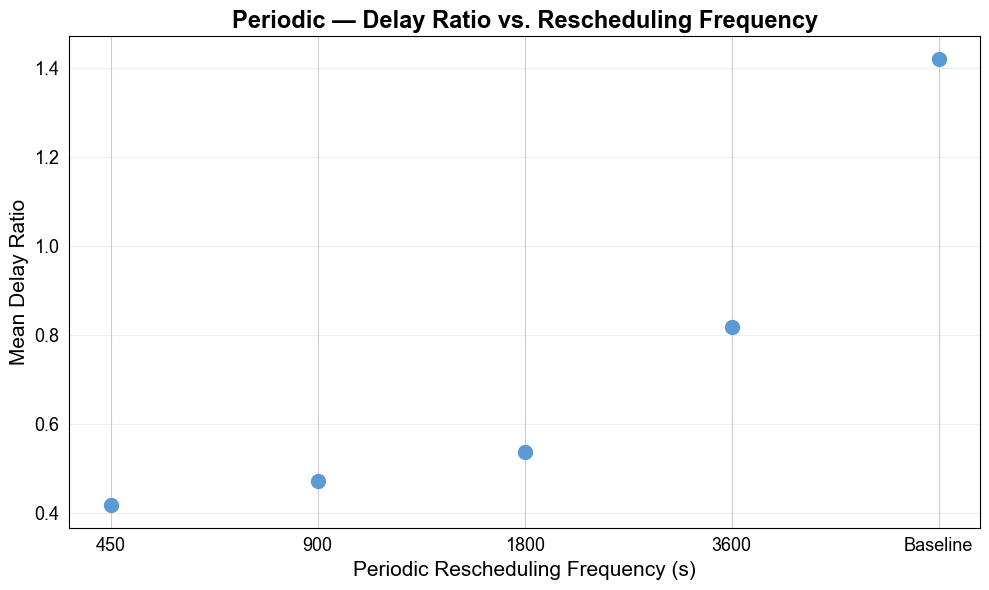

In [42]:
import matplotlib.pyplot as plt

scatter_df = (
    plot_df.groupby("label")
    .agg(
        mean_TED=("TED_combined", "mean"),
        mean_DR=("delay_ratio", "mean")
    )
    .reset_index()
)

# Add baseline
baseline_row = pd.DataFrame({
    "label": ["Baseline"],
    "mean_TED": [raw_periodic[raw_periodic["periodic_freq"] == 100000]["TED_combined"].mean()],
    "mean_DR": [raw_periodic[raw_periodic["periodic_freq"] == 100000]["delay_ratio"].mean()]
})
scatter_df = pd.concat([scatter_df, baseline_row], ignore_index=True)

# Clean x labels
scatter_df["x_label"] = scatter_df["label"].str.replace("P_", "").replace("P_100000", "Baseline")

# Order
x_order = ["450", "900", "1800", "3600", "Baseline"]
scatter_df["x_order"] = scatter_df["x_label"].map({v: i for i, v in enumerate(x_order)})
scatter_df = scatter_df.sort_values("x_order")

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(scatter_df["x_label"], scatter_df["mean_DR"],
           color="#5B9BD5", s=100, zorder=3)

ax.set_title("Periodic — Delay Ratio vs. Rescheduling Frequency", fontsize=17, fontweight="bold", color="black")
ax.set_xlabel("Periodic Rescheduling Frequency (s)", fontsize=15, color="black")
ax.set_ylabel("Mean Delay Ratio", fontsize=15, color="black")
ax.tick_params(colors="black", labelsize=13)
ax.spines["bottom"].set_color("black")
ax.spines["top"].set_color("black")
ax.spines["left"].set_color("black")
ax.spines["right"].set_color("black")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# HELPERS & AGGREGATIE voor TED vs. #Reschedules plots
# ============================================================

def get_pareto(df, x_col, y_col):
    pts = df[[x_col, y_col]].values.astype(float)
    n = len(pts)
    is_eff = np.ones(n, dtype=bool)
    for i in range(n):
        if not is_eff[i]:
            continue
        for j in range(n):
            if i == j or not is_eff[j]:
                continue
            if (pts[j, 0] <= pts[i, 0] and pts[j, 1] <= pts[i, 1] and
                    (pts[j, 0] < pts[i, 0] or pts[j, 1] < pts[i, 1])):
                is_eff[i] = False
                break
    return is_eff


def draw_pareto_line(ax, df_pareto, x_col, y_col, color, lw=1.5):
    pts = df_pareto.sort_values(x_col)
    ax.plot(pts[x_col], pts[y_col], color=color, linewidth=lw,
            linestyle="--", alpha=0.6, zorder=2)


def annotate_points(ax, df, x_col, y_col, label_col, fontsize=8.5, color="black"):
    offsets = [(7, 6), (7, -15), (-70, 6), (-70, -15), (7, 18), (7, -24),
               (-70, 18), (-70, -24), (7, 30), (-70, 30), (20, -24)]
    for idx, (_, row) in enumerate(df.iterrows()):
        off = offsets[idx % len(offsets)]
        ax.annotate(
            row[label_col],
            xy=(row[x_col], row[y_col]),
            xytext=off,
            textcoords="offset points",
            fontsize=fontsize,
            color=color,
            arrowprops=dict(arrowstyle="-", color="#999999", lw=0.6),
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8),
        )


def agg_config(df, group_cols):
    return (
        df[~df["deadlock"]]
        .groupby(group_cols)
        .agg(mean_TED=("TED_combined", "mean"), mean_n=("n_rescheduled", "mean"))
        .reset_index()
    )


def tc_str(v):
    return str(v).replace(".", ",")


# Kleuren
C_NORMAL    = "#BBBBBB"
C_PERIODIC  = "#2B7BB9"
C_BASELINE  = "#E05C00"
C_ED_PARETO = "#1A5C8A"
C_HY_PARETO = "#28826A"

SAVE_DIR = Path.cwd().parent / "TimingStrategies_28_05"

# Aggregeer per configuratie (excl. deadlocks)
p_agg = agg_config(raw_periodic, ["periodic_freq"])
p_agg["label_txt"] = p_agg["periodic_freq"].apply(
    lambda x: "Baseline" if x == 100000 else f"P: {int(x)}"
)

ed_agg = agg_config(raw_event,
                    ["event_driven_freq", "controller_freq", "threshold_confidence"])
ed_agg["label_txt"] = ed_agg.apply(
    lambda r: (f"E-RF:{int(r.event_driven_freq)} CF:{int(r.controller_freq)} "
               f"TC:{tc_str(r.threshold_confidence)}"),
    axis=1,
)
ed_agg["pareto"] = get_pareto(ed_agg, "mean_n", "mean_TED")

h_agg = agg_config(raw_hybrid,
                   ["event_driven_freq", "periodic_freq", "controller_freq",
                    "threshold_confidence"])
h_agg["label_txt"] = h_agg.apply(
    lambda r: (f"E-RF:{int(r.event_driven_freq)} P-RF:{int(r.periodic_freq)} "
               f"CF:{int(r.controller_freq)} TC:{tc_str(r.threshold_confidence)}"),
    axis=1,
)
h_agg["pareto"] = get_pareto(h_agg, "mean_n", "mean_TED")

print(f"Pareto-efficiënt — "
      f"Periodic: {len(p_agg)} configs | "
      f"Event-driven: {ed_agg['pareto'].sum()}/{len(ed_agg)} | "
      f"Hybrid: {h_agg['pareto'].sum()}/{len(h_agg)}")

Pareto-efficiënt — Periodic: 5 configs | Event-driven: 11/26 | Hybrid: 3/7


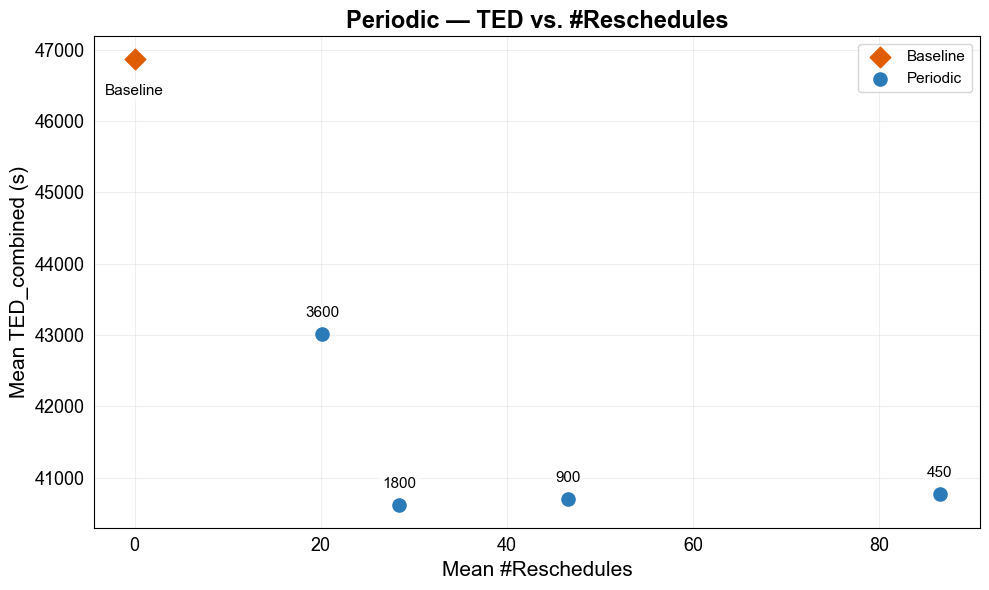

In [44]:
baseline_p = p_agg[p_agg["periodic_freq"] == 100000]
others_p   = p_agg[p_agg["periodic_freq"] != 100000]

p_agg["label_txt"] = p_agg["periodic_freq"].apply(
    lambda x: "Baseline" if x == 100000 else f"{int(x)}"
) 

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(baseline_p["mean_n"], baseline_p["mean_TED"],
           color=C_BASELINE, s=110, zorder=4, label="Baseline", marker="D")
ax.scatter(others_p["mean_n"], others_p["mean_TED"],
           color=C_PERIODIC, s=90, zorder=3, label="Periodic")

for _, row in p_agg.iterrows():
    is_baseline = row["periodic_freq"] == 100000
    ax.annotate(
        row["label_txt"],
        xy=(row["mean_n"], row["mean_TED"]),
        xytext=(0, -18 if is_baseline else 10),
        textcoords="offset points",
        fontsize=11,
        ha="center",
        va="top" if is_baseline else "bottom",
        color="black",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8),
    )

ax.set_title("Periodic — TED vs. #Reschedules", fontsize=17, fontweight="bold", color="black")
ax.set_xlabel("Mean #Reschedules", fontsize=15, color="black")
ax.set_ylabel("Mean TED_combined (s)", fontsize=15, color="black")
ax.tick_params(colors="black", labelsize=13)
ax.spines["bottom"].set_color("black")
ax.spines["top"].set_color("black")
ax.spines["left"].set_color("black")
ax.spines["right"].set_color("black")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(str(SAVE_DIR / "pareto_periodic.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## Event-Driven

In [9]:
raw_event = raw_all[raw_all["trigger_strategy"] == "event_driven"]
print(f"Event-driven runs: {len(raw_event)} | deadlocks: {raw_event['deadlock'].sum()}")
print(f"event_driven_freq waarden: {sorted(raw_event['event_driven_freq'].unique())}")
print(f"controller_freq waarden:   {sorted(raw_event['controller_freq'].unique())}")
print(f"threshold_confidence:      {sorted(raw_event['threshold_confidence'].unique())}")

Event-driven runs: 1300 | deadlocks: 35
event_driven_freq waarden: [np.float64(600.0), np.float64(900.0), np.float64(1800.0), np.float64(3600.0), np.float64(5400.0)]
controller_freq waarden:   [np.float64(300.0), np.float64(450.0), np.float64(600.0), np.float64(900.0), np.float64(1800.0), np.float64(3600.0), np.float64(5400.0)]
threshold_confidence:      [np.float64(0.4), np.float64(0.8)]


In [10]:
raw_event.columns

Index(['label', 'seed', 'trigger_strategy', 'event_driven_freq',
       'controller_freq', 'periodic_freq', 'threshold_confidence',
       'TED_combined', 'TED_passenger', 'TED_freight', 'delay_ratio',
       'n_delay_gt3min', 'n_delay_gt5min', 'max_end_delay', 'n_rescheduled',
       'n_evaluated', 'n_skipped_no_improvement', 'total_solve_time_s',
       'mean_solve_time_s', 'trigger_rate_pct', 'trigger_rate_mc_pct',
       'n_platform_switches', 'n_fcfs_fallback', 'deadlock'],
      dtype='str')

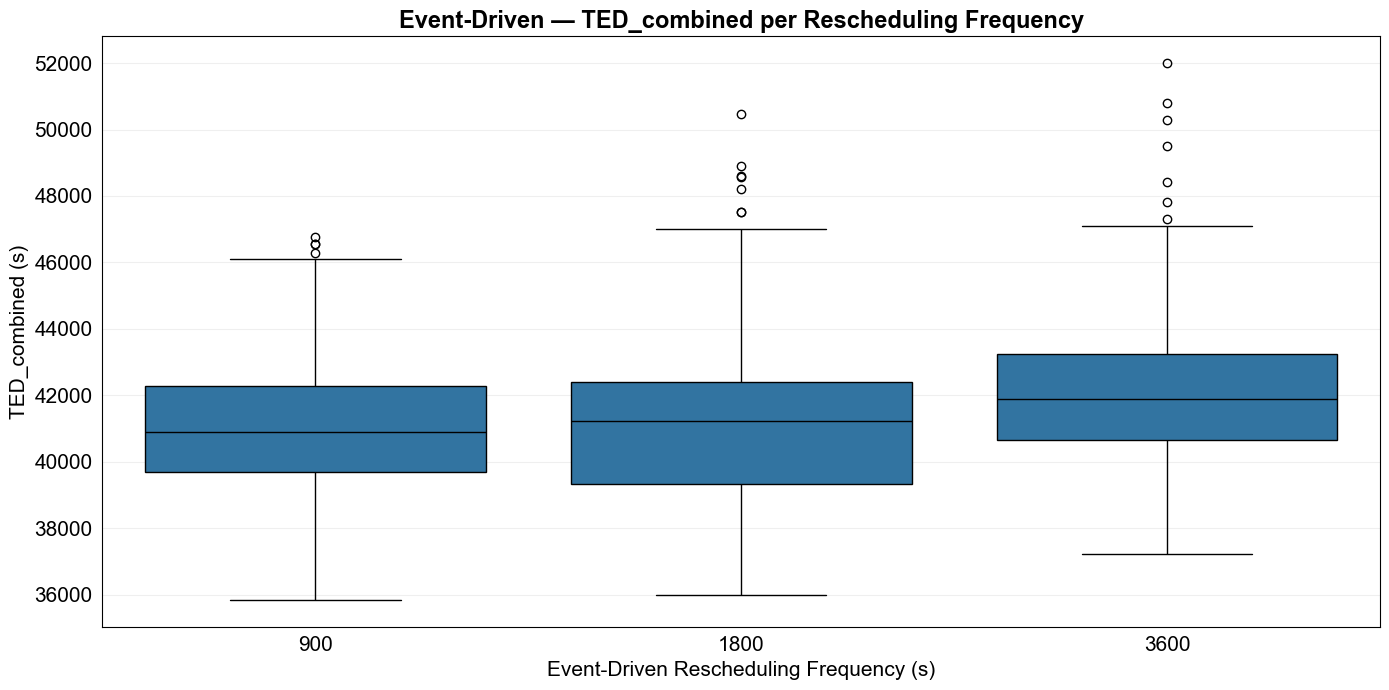

In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# FILTER COMPARABLE CONFIGURATIONS
# ============================================================

df = raw_event.copy()
df = df[df["controller_freq"] == 900]

valid_event_rf = [900, 1800, 3600]
df = df[df["event_driven_freq"].isin(valid_event_rf)]

plot_df = df[~df["deadlock"]].copy()
freq_order = sorted(valid_event_rf)

plot_df["event_driven_freq"] = plot_df["event_driven_freq"].astype(int)
freq_order = [int(f) for f in freq_order]

# ============================================================
# TED BOXPLOT
# ============================================================

fig, ax = plt.subplots(figsize=(14, 7))

sns.boxplot(
    data=plot_df,
    x="event_driven_freq",
    y="TED_combined",
    order=freq_order,
    ax=ax,
    linecolor="black",
    flierprops={"markeredgecolor": "black"}
)

ax.set_xticklabels([f"{int(f)}" for f in freq_order], fontsize=15)
ax.tick_params(axis="y", labelsize=15, colors="black")
ax.tick_params(axis="x", colors="black")
ax.spines["bottom"].set_color("black")
ax.spines["top"].set_color("black")
ax.spines["left"].set_color("black")
ax.spines["right"].set_color("black")
plt.title("Event-Driven — TED_combined per Rescheduling Frequency", fontsize=17, fontweight="bold", color="black")
plt.xlabel("Event-Driven Rescheduling Frequency (s)", fontsize=15, color="black")
plt.ylabel("TED_combined (s)", fontsize=15, color="black")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

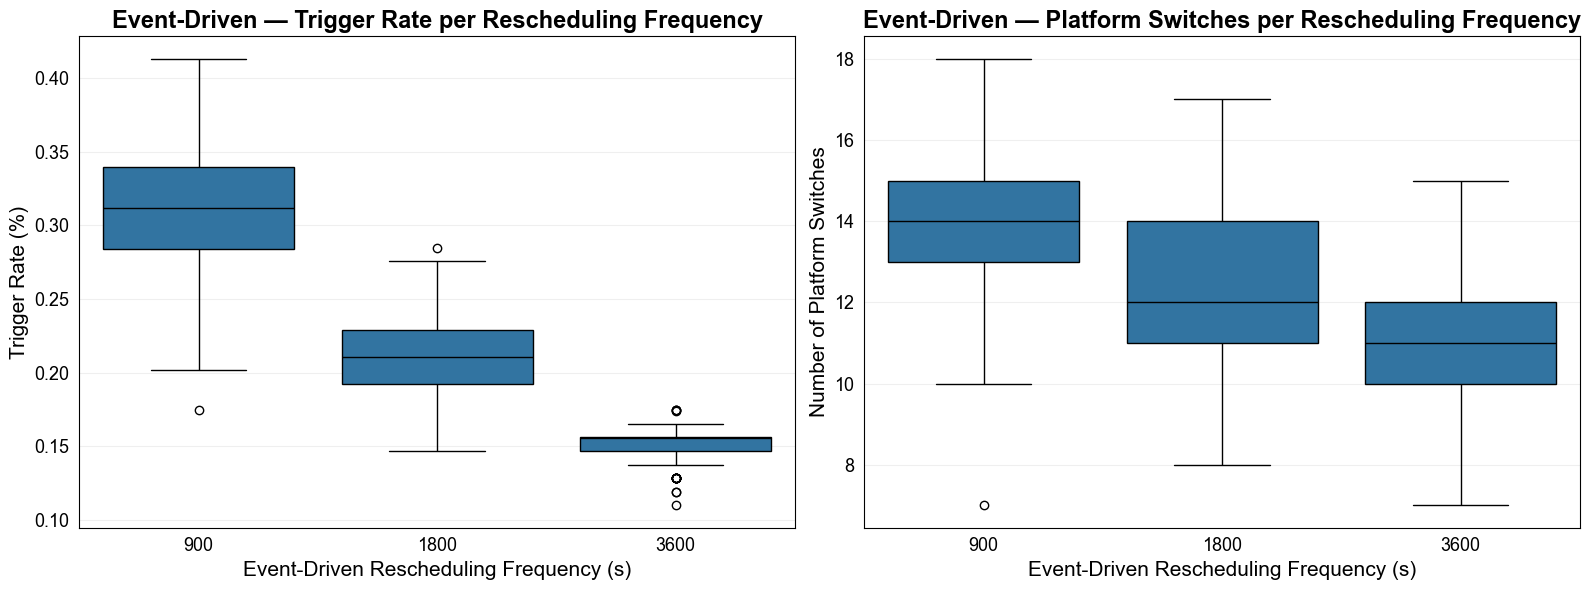

In [50]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# TRIGGER RATE ANALYSE (nieuw in 28/05 data)
# ============================================================

df = raw_event[~raw_event["deadlock"]].copy()
df = df[df["controller_freq"] == 900]
df = df[df["event_driven_freq"].isin([900, 1800, 3600])]

df["event_driven_freq"] = df["event_driven_freq"].astype(int)
freq_order = sorted(df["event_driven_freq"].unique())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# trigger_rate_pct
sns.boxplot(data=df, x="event_driven_freq", y="trigger_rate_pct",
            order=freq_order, ax=axes[0], linecolor="black",
            flierprops={"markeredgecolor": "black"})
axes[0].set_xticklabels([f"{int(f)}" for f in freq_order], fontsize=15)
axes[0].tick_params(colors="black", labelsize=13)
axes[0].spines["bottom"].set_color("black")
axes[0].spines["top"].set_color("black")
axes[0].spines["left"].set_color("black")
axes[0].spines["right"].set_color("black")
axes[0].set_title("Event-Driven — Trigger Rate per Rescheduling Frequency", fontsize=17, fontweight="bold", color="black")
axes[0].set_ylabel("Trigger Rate (%)", fontsize=15, color="black")
axes[0].set_xlabel("Event-Driven Rescheduling Frequency (s)", fontsize=15, color="black")

# n_platform_switches
sns.boxplot(data=df, x="event_driven_freq", y="n_platform_switches",
            order=freq_order, ax=axes[1], linecolor="black",
            flierprops={"markeredgecolor": "black"})
axes[1].set_xticklabels([f"{int(f)}" for f in freq_order], fontsize=15)
axes[1].tick_params(colors="black", labelsize=13)
axes[1].spines["bottom"].set_color("black")
axes[1].spines["top"].set_color("black")
axes[1].spines["left"].set_color("black")
axes[1].spines["right"].set_color("black")
axes[1].set_title("Event-Driven — Platform Switches per Rescheduling Frequency", fontsize=17, fontweight="bold", color="black")
axes[1].set_ylabel("Number of Platform Switches", fontsize=15, color="black")
axes[1].set_xlabel("Event-Driven Rescheduling Frequency (s)", fontsize=15, color="black")

for ax in axes:
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

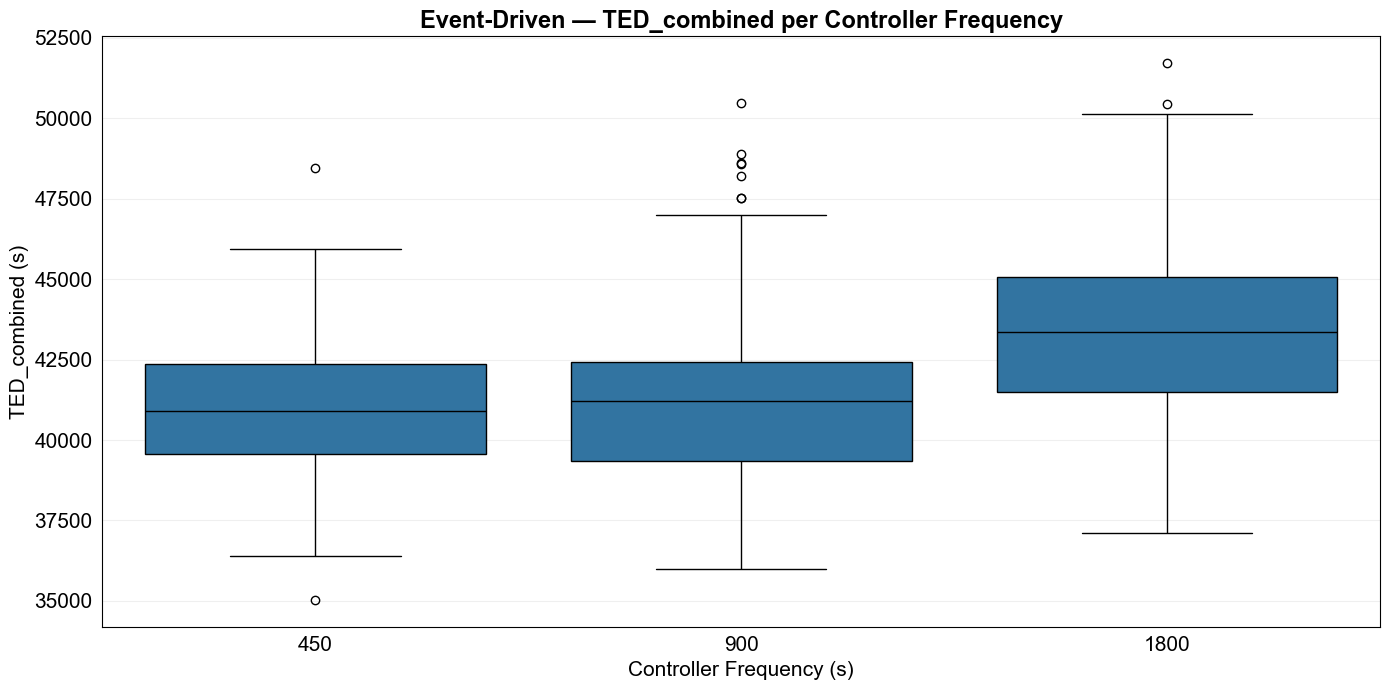

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# FILTER COMPARABLE CONFIGURATIONS
# ============================================================

df = raw_event.copy()
df = df[df["event_driven_freq"] == 1800]

valid_controller_freqs = [450, 900, 1800]
df = df[df["controller_freq"].isin(valid_controller_freqs)]

plot_df = df[~df["deadlock"]].copy()
plot_df["controller_freq"] = plot_df["controller_freq"].astype(int)
freq_order = [int(f) for f in sorted(valid_controller_freqs)]

# ============================================================
# TED BOXPLOT
# ============================================================

fig, ax = plt.subplots(figsize=(14, 7))

sns.boxplot(
    data=plot_df,
    x="controller_freq",
    y="TED_combined",
    order=freq_order,
    ax=ax,
    linecolor="black",
    flierprops={"markeredgecolor": "black"}
)

ax.set_xticklabels([f"{int(f)}" for f in freq_order], fontsize=15)
ax.tick_params(axis="y", labelsize=15, colors="black")
ax.tick_params(axis="x", colors="black")
ax.spines["bottom"].set_color("black")
ax.spines["top"].set_color("black")
ax.spines["left"].set_color("black")
ax.spines["right"].set_color("black")
plt.title("Event-Driven — TED_combined per Controller Frequency", fontsize=17, fontweight="bold", color="black")
plt.xlabel("Controller Frequency (s)", fontsize=15, color="black")
plt.ylabel("TED_combined (s)", fontsize=15, color="black")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


Methodological note:
threshold_confidence acts as a trigger sensitivity parameter rather than
a structural timing parameter, so pooling across configurations is acceptable
for exploratory analysis.



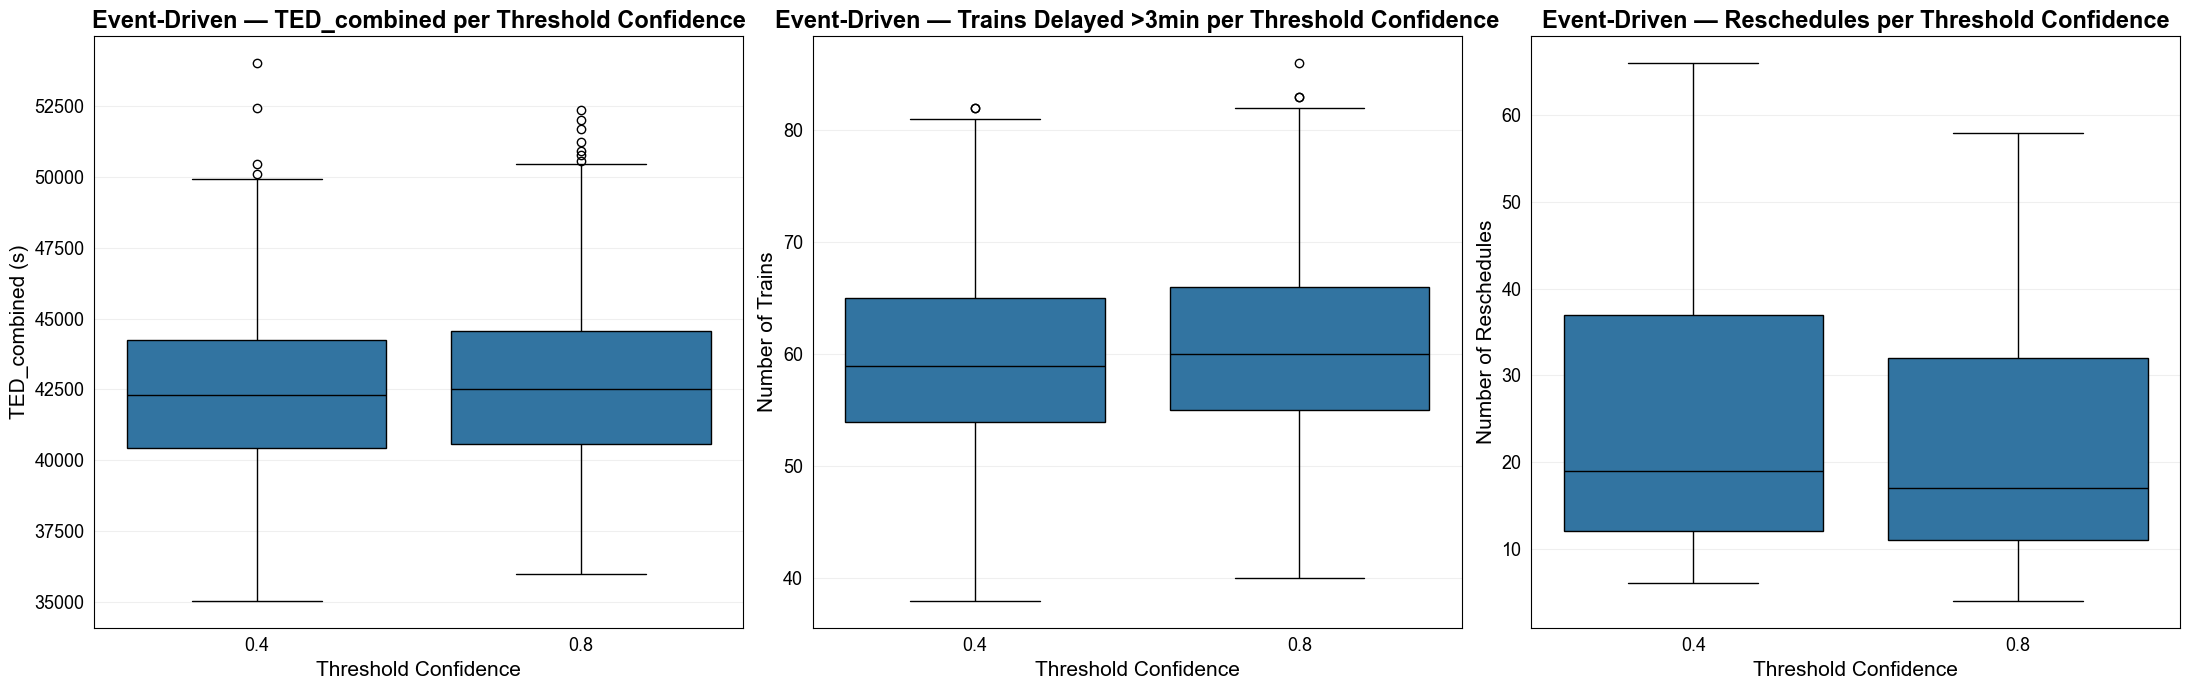

In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("""
Methodological note:
threshold_confidence acts as a trigger sensitivity parameter rather than
a structural timing parameter, so pooling across configurations is acceptable
for exploratory analysis.
""")

# ============================================================
# FILTER EVENT-DRIVEN STRATEGIES
# ============================================================

df = raw_event.copy()
plot_df = df[~df["deadlock"]].copy()

threshold_order = sorted(plot_df["threshold_confidence"].unique())

# ============================================================
# STATISTICS
# ============================================================

stats_df = (
    df.groupby("threshold_confidence")
    .agg(
        deadlocks=("deadlock", "sum"),
        mean_TED=("TED_combined", "mean"),
        std_TED=("TED_combined", "std"),
        mean_n_delay=("n_delay_gt3min", "mean"),
        std_n_delay=("n_delay_gt3min", "std"),
        mean_reschedules=("n_rescheduled", "mean"),
        std_reschedules=("n_rescheduled", "std"),
    )
    .reindex(threshold_order)
)

# ============================================================
# PLOTTING
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# TED
sns.boxplot(data=plot_df, x="threshold_confidence", y="TED_combined",
            order=threshold_order, ax=axes[0], linecolor="black",
            flierprops={"markeredgecolor": "black"})
axes[0].set_xticklabels([f"{c}" for c in threshold_order], fontsize=15)
axes[0].tick_params(colors="black", labelsize=13)
axes[0].spines["bottom"].set_color("black")
axes[0].spines["top"].set_color("black")
axes[0].spines["left"].set_color("black")
axes[0].spines["right"].set_color("black")
axes[0].set_title("Event-Driven — TED_combined per Threshold Confidence", fontsize=17, fontweight="bold", color="black")
axes[0].set_xlabel("Threshold Confidence", fontsize=15, color="black")
axes[0].set_ylabel("TED_combined (s)", fontsize=15, color="black")

# n_delay_gt3min
sns.boxplot(data=plot_df, x="threshold_confidence", y="n_delay_gt3min",
            order=threshold_order, ax=axes[1], linecolor="black",
            flierprops={"markeredgecolor": "black"})
axes[1].set_xticklabels([f"{c}" for c in threshold_order], fontsize=15)
axes[1].tick_params(colors="black", labelsize=13)
axes[1].spines["bottom"].set_color("black")
axes[1].spines["top"].set_color("black")
axes[1].spines["left"].set_color("black")
axes[1].spines["right"].set_color("black")
axes[1].set_title("Event-Driven — Trains Delayed >3min per Threshold Confidence", fontsize=17, fontweight="bold", color="black")
axes[1].set_xlabel("Threshold Confidence", fontsize=15, color="black")
axes[1].set_ylabel("Number of Trains", fontsize=15, color="black")

# Reschedules
sns.boxplot(data=plot_df, x="threshold_confidence", y="n_rescheduled",
            order=threshold_order, ax=axes[2], linecolor="black",
            flierprops={"markeredgecolor": "black"})
axes[2].set_xticklabels([f"{c}" for c in threshold_order], fontsize=15)
axes[2].tick_params(colors="black", labelsize=13)
axes[2].spines["bottom"].set_color("black")
axes[2].spines["top"].set_color("black")
axes[2].spines["left"].set_color("black")
axes[2].spines["right"].set_color("black")
axes[2].set_title("Event-Driven — Reschedules per Threshold Confidence", fontsize=17, fontweight="bold", color="black")
axes[2].set_xlabel("Threshold Confidence", fontsize=15, color="black")
axes[2].set_ylabel("Number of Reschedules", fontsize=15, color="black")

for ax in axes:
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

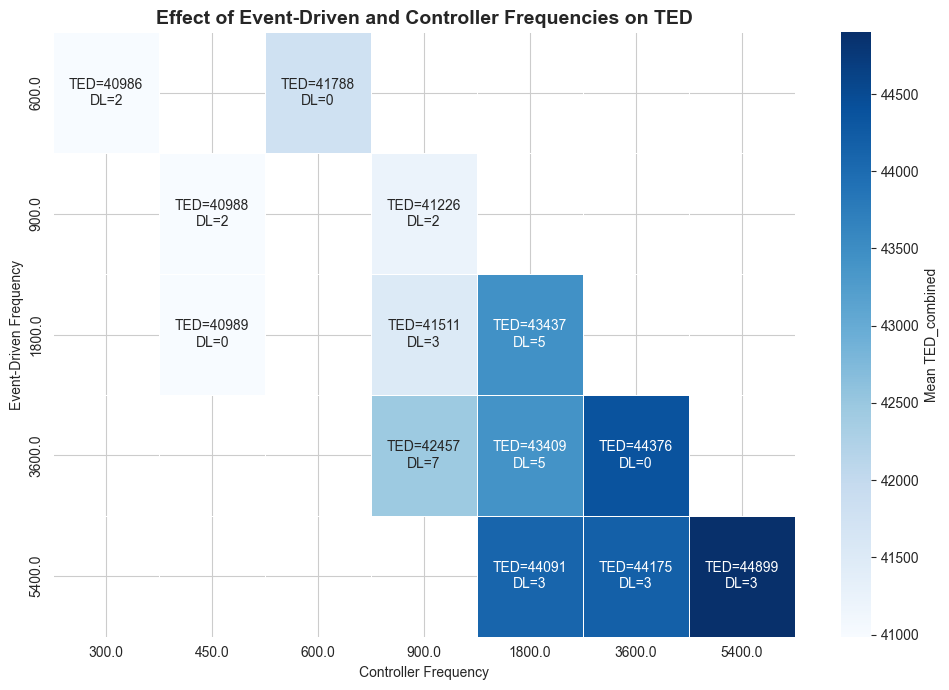

In [57]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# PREPARE DATA
# ============================================================

df = raw_event.copy()
plot_df = df[~df["deadlock"]].copy()

# ============================================================
# AGGREGATE MEAN TED
# ============================================================

heatmap_data = (
    plot_df
    .groupby(["event_driven_freq", "controller_freq"])["TED_combined"]
    .mean()
    .reset_index()
)

pivot_ted = heatmap_data.pivot(
    index="event_driven_freq",
    columns="controller_freq",
    values="TED_combined"
)

# ============================================================
# DEADLOCK COUNTS
# ============================================================

pivot_dl = (
    df.groupby(["event_driven_freq", "controller_freq"])["deadlock"]
    .sum()
    .reset_index()
    .pivot(index="event_driven_freq", columns="controller_freq", values="deadlock")
)

# ============================================================
# BUILD ANNOTATIONS
# ============================================================

annotations = pivot_ted.copy().astype(str)

for i in pivot_ted.index:
    for j in pivot_ted.columns:
        ted = pivot_ted.loc[i, j]
        dl  = pivot_dl.loc[i, j] if (i in pivot_dl.index and j in pivot_dl.columns) else 0
        if pd.isna(ted):
            annotations.loc[i, j] = ""
        else:
            annotations.loc[i, j] = f"TED={ted:.0f}\nDL={int(dl)}"

# ============================================================
# PLOT HEATMAP
# ============================================================

plt.figure(figsize=(10, 7))

sns.heatmap(
    pivot_ted,
    annot=annotations,
    fmt="",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Mean TED_combined"}
)

plt.title("Effect of Event-Driven and Controller Frequencies on TED", fontsize=14, fontweight="bold")
plt.xlabel("Controller Frequency")
plt.ylabel("Event-Driven Frequency")
plt.tight_layout()
plt.show()

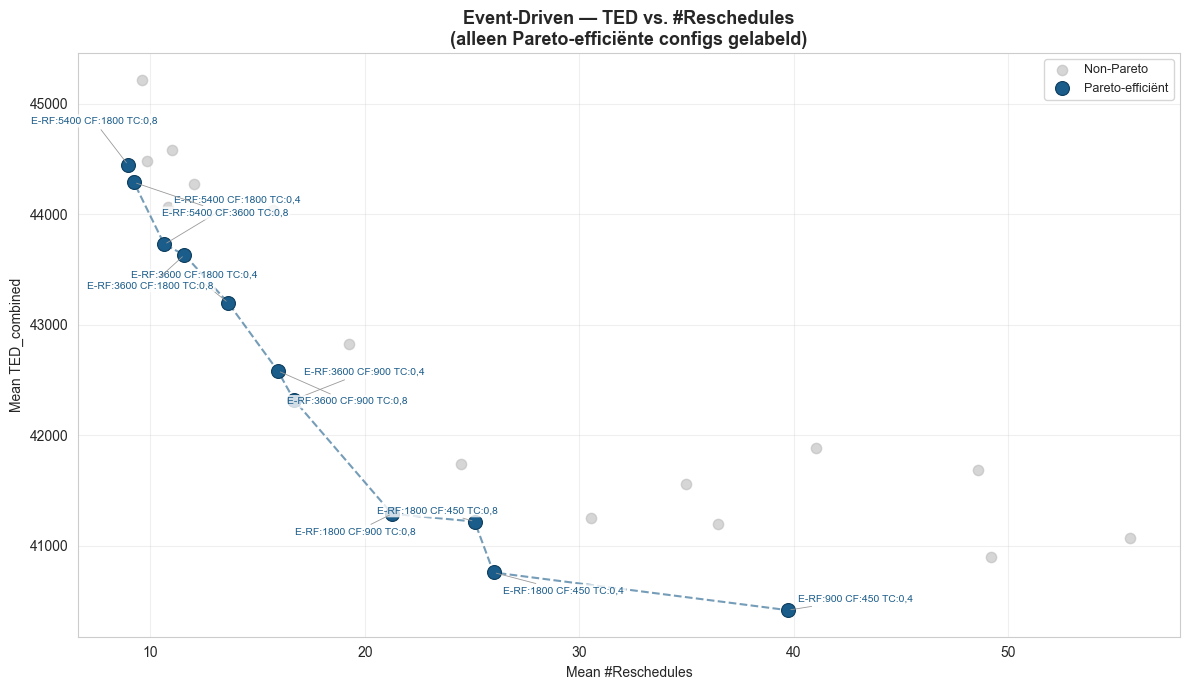

In [58]:
ed_non_p = ed_agg[~ed_agg["pareto"]]
ed_par   = ed_agg[ ed_agg["pareto"]]

fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(ed_non_p["mean_n"], ed_non_p["mean_TED"],
           color=C_NORMAL, s=55, zorder=2, alpha=0.6, label="Non-Pareto")
ax.scatter(ed_par["mean_n"], ed_par["mean_TED"],
           color=C_ED_PARETO, s=100, zorder=3, label="Pareto-efficiënt",
           edgecolors="#0d3d5e", linewidths=0.8)
draw_pareto_line(ax, ed_par, "mean_n", "mean_TED", color=C_ED_PARETO)
annotate_points(ax, ed_par, "mean_n", "mean_TED", "label_txt",
                fontsize=7.5, color=C_ED_PARETO)
ax.set_title("Event-Driven — TED vs. #Reschedules\n(alleen Pareto-efficiënte configs gelabeld)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Mean #Reschedules")
ax.set_ylabel("Mean TED_combined")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(str(SAVE_DIR / "pareto_event_driven.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## Hybrid

In [ ]:
raw_hybrid = raw_all[raw_all["trigger_strategy"] == "hybrid"]
print(f"Hybrid runs: {len(raw_hybrid)} | deadlocks: {raw_hybrid['deadlock'].sum()}")
print(f"event_driven_freq waarden: {sorted(raw_hybrid['event_driven_freq'].unique())}")
print(f"periodic_freq waarden:     {sorted(raw_hybrid['periodic_freq'].unique())}")
print(f"Configuraties (label, n seeds):")
print(raw_hybrid.groupby("label").size().to_string())

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# PREPARE DATA
# ============================================================

df = raw_hybrid.copy()
plot_df = df[~df["deadlock"]].copy()

# ============================================================
# AGGREGATE MEAN TED per (event_driven_freq, periodic_freq)
# ============================================================

heatmap_data = (
    plot_df
    .groupby(["event_driven_freq", "periodic_freq"])["TED_combined"]
    .mean()
    .reset_index()
)

pivot_ted = heatmap_data.pivot(
    index="event_driven_freq",
    columns="periodic_freq",
    values="TED_combined"
)

# ============================================================
# DEADLOCK COUNTS
# ============================================================

pivot_dl = (
    df.groupby(["event_driven_freq", "periodic_freq"])["deadlock"]
    .sum()
    .reset_index()
    .pivot(index="event_driven_freq", columns="periodic_freq", values="deadlock")
)

# ============================================================
# BUILD ANNOTATIONS
# ============================================================

annotations = pivot_ted.copy().astype(str)

for i in pivot_ted.index:
    for j in pivot_ted.columns:
        ted = pivot_ted.loc[i, j]
        dl  = pivot_dl.loc[i, j] if (i in pivot_dl.index and j in pivot_dl.columns) else 0
        if pd.isna(ted):
            annotations.loc[i, j] = ""
        else:
            annotations.loc[i, j] = f"TED={ted:.0f}\nDL={int(dl)}"

# ============================================================
# PLOT HEATMAP
# ============================================================

plt.figure(figsize=(10, 5))

sns.heatmap(
    pivot_ted,
    annot=annotations,
    fmt="",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Mean TED_combined"}
)

plt.title("Hybrid: Effect of Event-Driven and Periodic Frequencies on TED", fontsize=14, fontweight="bold")
plt.xlabel("Periodic Frequency")
plt.ylabel("Event-Driven Frequency")
plt.tight_layout()
plt.show()

# ============================================================
# BOXPLOT: TED per label (threshold_confidence × periodic_freq)
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))
label_order = sorted(plot_df["label"].unique())

sns.boxplot(data=plot_df, x="label", y="TED_combined", order=label_order, ax=ax)
ax.set_xticklabels(label_order, rotation=30, ha="right")
ax.set_title("TED_combined per hybrid configuratie", fontsize=12, fontweight="bold")
ax.set_xlabel("Configuratie label")
ax.set_ylabel("TED_combined")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
h_non_p = h_agg[~h_agg["pareto"]]
h_par   = h_agg[ h_agg["pareto"]]

fig, ax = plt.subplots(figsize=(12, 6))
if len(h_non_p):
    ax.scatter(h_non_p["mean_n"], h_non_p["mean_TED"],
               color=C_NORMAL, s=55, zorder=2, alpha=0.6, label="Non-Pareto")
ax.scatter(h_par["mean_n"], h_par["mean_TED"],
           color=C_HY_PARETO, s=100, zorder=3, label="Pareto-efficiënt",
           edgecolors="#1a5244", linewidths=0.8)
draw_pareto_line(ax, h_par, "mean_n", "mean_TED", color=C_HY_PARETO)
annotate_points(ax, h_par, "mean_n", "mean_TED", "label_txt",
                fontsize=8, color=C_HY_PARETO)
n_incomplete = (raw_hybrid.groupby("label").size() < 50).sum()
if n_incomplete:
    ax.text(0.01, 0.02,
            f"Let op: {n_incomplete} config(s) hebben < 50 seeds (simulatie loopt nog)",
            transform=ax.transAxes, fontsize=8, color="#888888", va="bottom")
ax.set_title("Hybrid — TED vs. #Reschedules\n(alleen Pareto-efficiënte configs gelabeld)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Mean #Reschedules")
ax.set_ylabel("Mean TED_combined")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(str(SAVE_DIR / "pareto_hybrid.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## Combined

In [ ]:
fig, ax = plt.subplots(figsize=(14, 8))

# Periodic
ax.scatter(baseline_p["mean_n"], baseline_p["mean_TED"],
           color=C_BASELINE, s=110, zorder=5, label="Baseline", marker="D")
ax.scatter(others_p["mean_n"], others_p["mean_TED"],
           color=C_PERIODIC, s=80, zorder=4, label="Periodic")
annotate_points(ax, p_agg, "mean_n", "mean_TED", "label_txt", fontsize=8)

# Event-Driven
ax.scatter(ed_non_p["mean_n"], ed_non_p["mean_TED"],
           color=C_NORMAL, s=45, zorder=2, alpha=0.5, label="Event-Driven (non-Pareto)")
ax.scatter(ed_par["mean_n"], ed_par["mean_TED"],
           color=C_ED_PARETO, s=90, zorder=4, label="Event-Driven (Pareto)",
           edgecolors="#0d3d5e", linewidths=0.7)
draw_pareto_line(ax, ed_par, "mean_n", "mean_TED", color=C_ED_PARETO)
annotate_points(ax, ed_par, "mean_n", "mean_TED", "label_txt", fontsize=7, color=C_ED_PARETO)

# Hybrid
if len(h_non_p):
    ax.scatter(h_non_p["mean_n"], h_non_p["mean_TED"],
               color="#CCCCCC", s=45, zorder=2, alpha=0.5, label="Hybrid (non-Pareto)")
ax.scatter(h_par["mean_n"], h_par["mean_TED"],
           color=C_HY_PARETO, s=90, zorder=4, label="Hybrid (Pareto)",
           edgecolors="#1a5244", linewidths=0.7)
draw_pareto_line(ax, h_par, "mean_n", "mean_TED", color=C_HY_PARETO)
annotate_points(ax, h_par, "mean_n", "mean_TED", "label_txt", fontsize=7, color=C_HY_PARETO)

ax.set_title("Alle strategieën — TED vs. #Reschedules\n(Pareto-efficiënte configs gelabeld per strategie)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Mean #Reschedules")
ax.set_ylabel("Mean TED_combined")
ax.legend(fontsize=8, loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(str(SAVE_DIR / "pareto_combined.png"), dpi=150, bbox_inches="tight")
plt.show()